In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

#### Load Sensor Data

In [2]:
field_data = pd.read_excel('/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/data/hrms_by_sensor.xlsx')

sensors_data = pd.read_csv(f"/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/data/sensores_data_UTM.txt")

# Create an array with the sensors positions
# Add 500 m to the distance to match the model
sensors_data["Distance"] += 500
sensor_names = sensors_data["Sensor"].values
sensors_positions = sensors_data["Distance"].values

#### Load OpenFoam Data 

In [3]:
hours_ok = [ 1, 2, 3, 4, 5, 6, 7, 8]
hours_ok = [1,2,7]

In [4]:
#wave_gauge_data = pd.read_csv('/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/outputs/molokai_cases_problem_refined/0000/wave_gauges.csv')
hrms_foam_per_hour_laminar = []

for i in hours_ok:
    wave_gauge_postprocessed = pd.read_csv(f'/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/outputs/molokai_dynamic_cases_copy/000{i}/wave_gauges_postprocessed.csv')
    hrms_foam_per_hour_laminar.append(wave_gauge_postprocessed['Hrms'].values)
    
hrms_foam_per_hour_komega = []

for i in hours_ok:
    wave_gauge_postprocessed = pd.read_csv(f'/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/outputs/molokai_dynamic_cases/000{i}/wave_gauges_postprocessed.csv')
    hrms_foam_per_hour_komega.append(wave_gauge_postprocessed['Hrms'].values)

In [5]:
wave_loc = pd.read_csv("/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/outputs/molokai_cases_problem_refined/0000/postProcessing/surfaceElevationAnyName/0/surfaceElevation.dat", sep="\t")
wave_loc = wave_loc.iloc[:3]
wave_loc

,Time,gauge_0,gauge_1,gauge_2,gauge_3,gauge_4,gauge_5,gauge_6,gauge_7,gauge_8,...,gauge_390,gauge_391,gauge_392,gauge_393,gauge_394,gauge_395,gauge_396,gauge_397,gauge_398,gauge_399
0,-1.0,0.00,4.51128,9.02256,13.5338,18.0451,22.5564,27.0677,31.5789,36.0902,...,1759.40000,1763.910000,1768.420000,1772.930000,1777.440000,1781.95000,1786.470000,1790.980000,1795.490000,1800.000000
1,-2.0,-10.00,-9.82000,-9.82000,-9.8200,-9.8200,-9.8200,-9.8200,-9.8200,-9.8200,...,-0.61039,-0.688312,-0.662338,-0.636364,-0.636364,-0.61039,-0.584416,-0.584416,-0.584416,-0.584416
2,-3.0,0.05,0.05000,0.05000,0.0500,0.0500,0.0500,0.0500,0.0500,0.0500,...,0.05000,0.050000,0.050000,0.050000,0.050000,0.05000,0.050000,0.050000,0.050000,0.050000


#### Load Swash data

In [6]:
swash_postprocessed = xr.open_dataset('/lustre/geocean/WORK/users/alonsoap/personal/estancia_NUS_2026/HyCFD/outputs/swash_molokai_dynamic_cases/output_postprocessed.nc')

In [7]:
swash_postprocessed

<xarray.Dataset> Size: 2MB
Dimensions:   (case_num: 10, Tsec: 8281, Xp: 2002)
Coordinates:
  * Tsec      (Tsec) int64 66kB 0 1 2 3 4 5 6 ... 8275 8276 8277 8278 8279 8280
  * Xp        (Xp) int64 16kB 0 1 2 3 4 5 6 ... 1996 1997 1998 1999 2000 2001
  * case_num  (case_num) int64 80B 0 1 2 3 4 5 6 7 8 9
    Yp        int64 8B ...
Data variables:
    Ru2       (case_num) float64 80B ...
    Runlev    (case_num, Tsec) float64 662kB ...
    Msetup    (case_num, Xp) float64 160kB ...
    Hrms      (case_num, Xp) float64 160kB ...
    Hs        (case_num, Xp) float64 160kB ...
    Hss       (case_num, Xp) float64 160kB ...
    ig        (case_num, Xp) float64 160kB ...
    Hvlf      (case_num, Xp) float64 160kB ...

#### Plot Cases

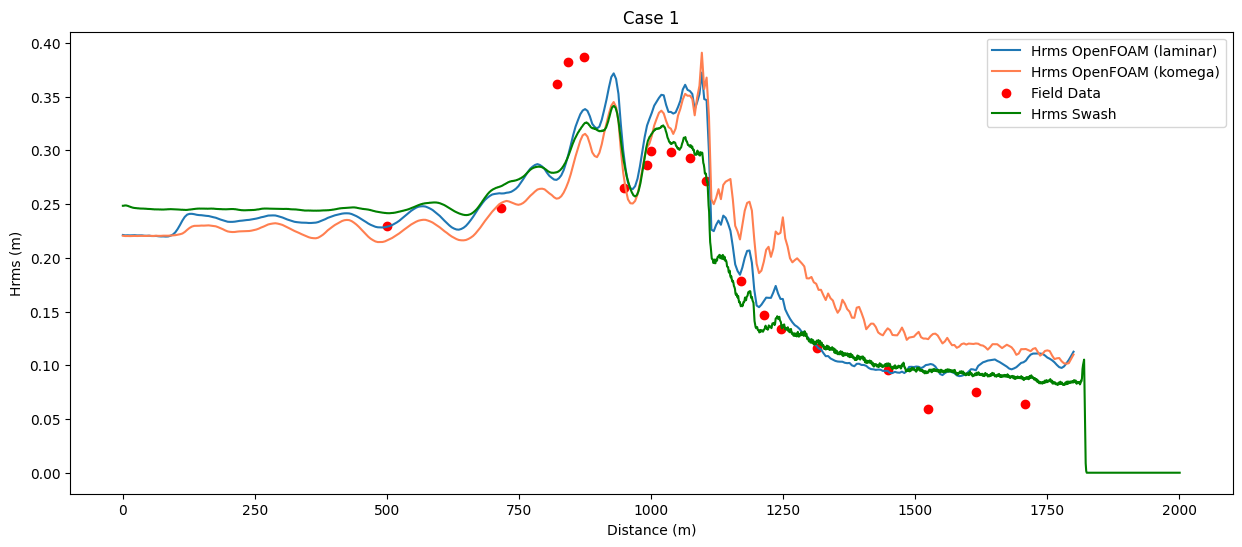

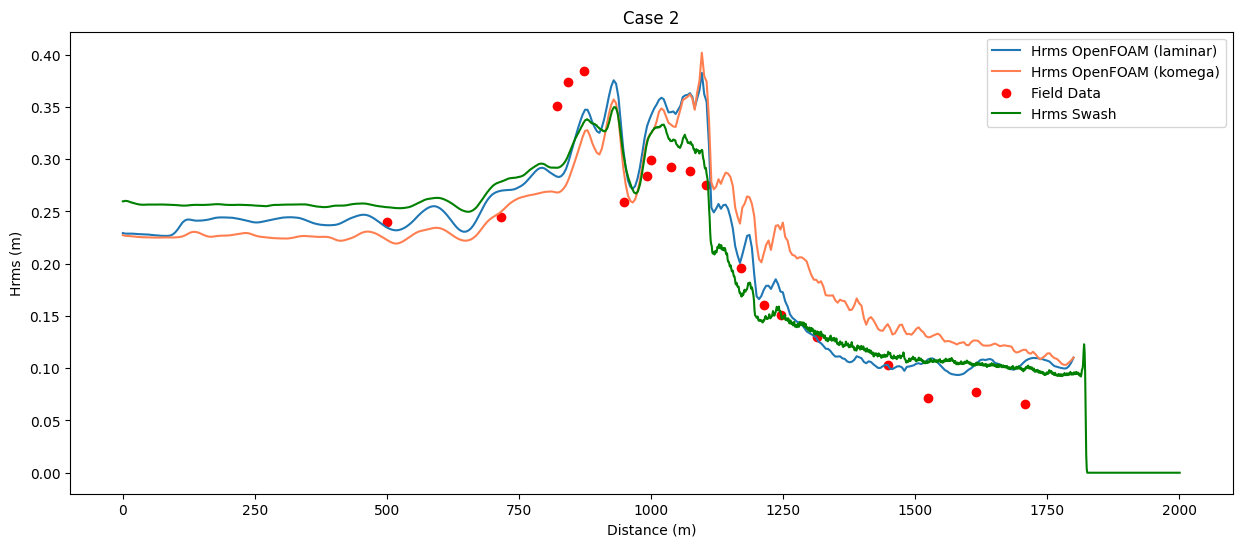

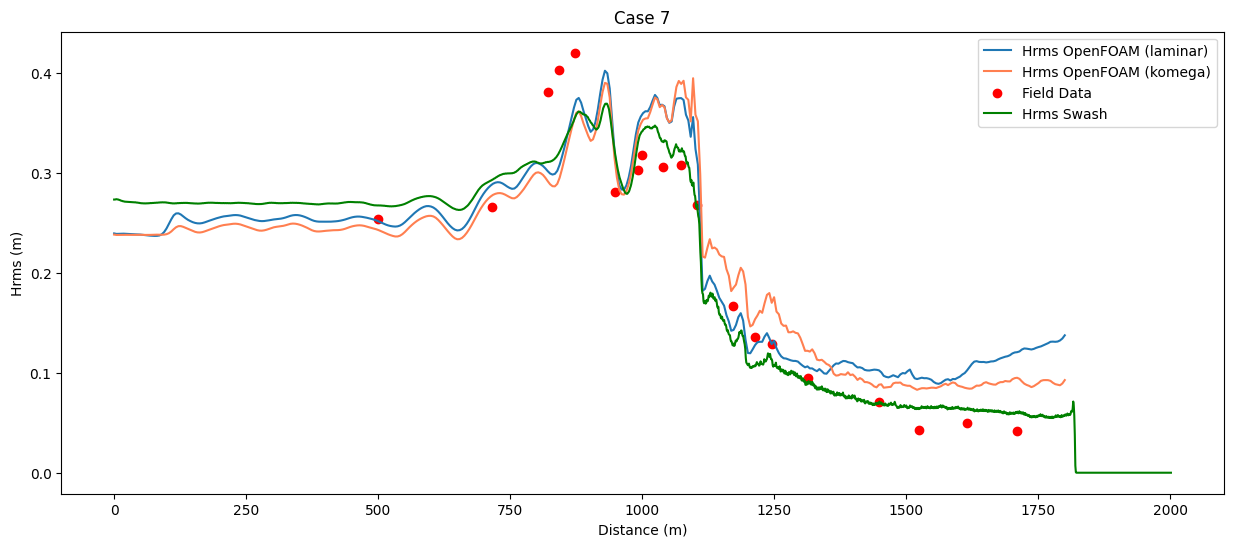

In [9]:
for i in range(len(hours_ok)):

    x = wave_loc.iloc[0].values[1:]
    y = hrms_foam_per_hour_laminar[i]

    x_komega = wave_loc.iloc[0].values[1:]
    y_komega = hrms_foam_per_hour_komega[i]

    x_swash = swash_postprocessed.Xp.values
    y_swash = swash_postprocessed.isel(case_num=hours_ok[i]).Hrms.values

    fig, axes = plt.subplots(1,1, figsize=(15,6))

    axes.plot(x, y, label='Hrms OpenFOAM (laminar)')
    axes.plot(x_komega, y_komega, color = "coral", label='Hrms OpenFOAM (komega)')
    axes.scatter(sensors_positions, field_data.iloc[hours_ok[i]].values, color='red', label='Field Data')
    axes.plot(x_swash, y_swash, color = "green", label='Hrms Swash')
    axes.set_xlabel('Distance (m)')
    axes.set_ylabel('Hrms (m)')
    axes.set_title(f'Case {hours_ok[i]}')


    axes.legend()

    plt.show()